# 07 — IRB Scope, Eligibility and Four Risk Components

## Opening the IRB calculation

The Standardised Approach is complete. This notebook begins IRB by separating PD, LGD, EAD and maturity and by showing where own estimates are used or restricted.

The four risk components enter the Basel IRB capital functions. The output is unexpected-loss capital K and IRB Credit RWA.

### The IRB approaches referred to below

| Term | Simple meaning |
|---|---|
| IRB | Internal Ratings-Based approach |
| A-IRB | Advanced IRB, using eligible own estimates of LGD and EAD as well as PD |
| F-IRB | Foundation IRB, using supervisory LGD or EAD parameters where required |
| Retail IRB | retail treatment using pool-level own estimates and retail risk functions |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from basel_credit_risk.config import load_all_config
from basel_credit_risk.notebook_support import display, ensure_outputs

CRORE = 10_000_000
COLORS = ["#0B3A53", "#1F77B4", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51"]
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
configs = load_all_config(ROOT / "config")
ensure_outputs(ROOT)
loans = pd.read_csv(ROOT / "data/processed/current_calculated.csv.gz", low_memory=False)
print(f"Portfolio represented: {len(loans):,} synthetic exposures")

Portfolio represented: 30,000 synthetic exposures


## The four loan-level IRB components

The table keeps parameter estimation separate from the final formula. Each component receives its own notebook before capital K is calculated.

In [2]:
components = pd.DataFrame([
    ["PD", "Long-run average one-year default rate for a borrower grade or retail pool", "Borrower or pool"],
    ["LGD", "Economic loss percentage under downturn conditions", "Facility"],
    ["EAD", "Funded exposure plus expected conversion of undrawn commitments", "Facility"],
    ["M", "Effective remaining maturity, where the risk function uses it", "Facility"],
], columns=["Component", "Meaning", "Primary level"])
display(components)

,Component,Meaning,Primary level
0,PD,Long-run average one-year default rate for a borrower grade or retail pool,Borrower or pool
1,LGD,Economic loss percentage under downturn conditions,Facility
2,EAD,Funded exposure plus expected conversion of undrawn commitments,Facility
3,M,"Effective remaining maturity, where the risk function uses it",Facility


## How the four components meet in the capital formula

PD describes the borrower or pool. LGD, EAD and maturity describe the facility. PD, LGD and applicable maturity treatment produce capital K through the Basel risk function. EAD then scales K into a monetary capital amount and RWA.

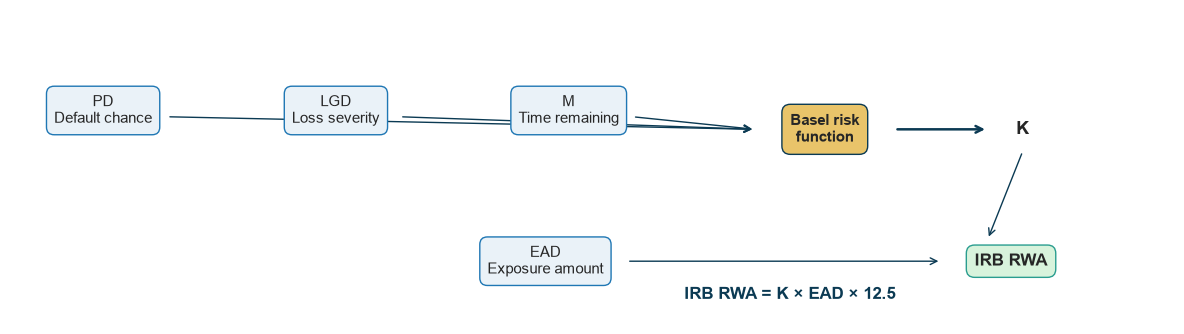

In [3]:
figure, axis = plt.subplots(figsize=(12, 3.5))
axis.axis("off")
risk_inputs = [(0.08, "PD\nDefault chance"), (0.28, "LGD\nLoss severity"), (0.48, "M\nTime remaining")]
for x, label in risk_inputs:
    axis.text(x, 0.68, label, ha="center", va="center", fontsize=11,
              bbox={"boxstyle": "round,pad=0.5", "facecolor": "#EAF2F8", "edgecolor": "#1F77B4"})
    axis.annotate("", xy=(0.64, 0.62), xytext=(x + 0.055, 0.66),
                  arrowprops={"arrowstyle": "->", "color": "#0B3A53"})
axis.text(0.70, 0.62, "Basel risk\nfunction", ha="center", va="center", fontsize=11, weight="bold",
          bbox={"boxstyle": "round,pad=0.55", "facecolor": "#E9C46A", "edgecolor": "#0B3A53"})
axis.annotate("", xy=(0.84, 0.62), xytext=(0.76, 0.62), arrowprops={"arrowstyle": "->", "color": "#0B3A53", "lw": 1.8})
axis.text(0.87, 0.62, "K", ha="center", va="center", fontsize=13, weight="bold")

axis.text(0.46, 0.20, "EAD\nExposure amount", ha="center", va="center", fontsize=11,
          bbox={"boxstyle": "round,pad=0.5", "facecolor": "#EAF2F8", "edgecolor": "#1F77B4"})
axis.text(0.86, 0.20, "IRB RWA", ha="center", va="center", fontsize=12, weight="bold",
          bbox={"boxstyle": "round,pad=0.5", "facecolor": "#D8F3DC", "edgecolor": "#2A9D8F"})
axis.annotate("", xy=(0.80, 0.20), xytext=(0.53, 0.20), arrowprops={"arrowstyle": "->", "color": "#0B3A53"})
axis.annotate("", xy=(0.84, 0.27), xytext=(0.87, 0.55), arrowprops={"arrowstyle": "->", "color": "#0B3A53"})
axis.text(0.67, 0.08, "IRB RWA = K × EAD × 12.5", ha="center", fontsize=12, weight="bold", color="#0B3A53")
plt.tight_layout()
plt.show()

The arrows explain the division of work across the following notebooks. PD and LGD measure risk, EAD scales it into money, and maturity modifies applicable non-retail capital. Correlation is prescribed later inside the risk function.

PD is primarily tied to borrower grade for corporate, bank and sovereign exposures and to pools for retail. LGD, EAD and maturity depend more directly on facility structure, collateral, recovery and commitment terms.

## Parameter source used in the educational engine

The represented Basel restrictions exclude own LGD estimates for bank exposures and general corporates above the sales threshold. Retail has its own IRB treatment. The field below prevents the project from calling every row A-IRB.

In [4]:
parameter_sources = loans.groupby(["performing_exposure_class", "irb_parameter_source", "airb_restriction_flag"], as_index=False).agg(
    loans=("exposure_id", "count"),
    ead=("ead_irb", "sum"),
)
parameter_sources["ead"] /= CRORE
display(parameter_sources.rename(columns={"ead": "IRB EAD (INR crore)"}))

,performing_exposure_class,irb_parameter_source,airb_restriction_flag,loans,IRB EAD (INR crore)
0,bank,FOUNDATION_SUPERVISORY_PARAMETERS,True,1050,86474.136168
1,corporate,FOUNDATION_SUPERVISORY_PARAMETERS,True,1020,144059.766513
2,corporate,OWN_ESTIMATE_PARAMETERS,False,2016,326176.955691
3,corporate_sme,OWN_ESTIMATE_PARAMETERS,False,2964,29069.740992
4,other,OWN_ESTIMATE_PARAMETERS,False,600,1294.415042
5,regulatory_retail,RETAIL_IRB_OWN_ESTIMATES,False,6000,482.927556
6,residential_real_estate,RETAIL_IRB_OWN_ESTIMATES,False,9600,4269.668168
7,retail_transactor,RETAIL_IRB_OWN_ESTIMATES,False,1331,18.254164
8,revolving_retail,RETAIL_IRB_OWN_ESTIMATES,False,4669,63.846535
9,sovereign,OWN_ESTIMATE_PARAMETERS,False,750,139386.419477


`OWN_ESTIMATE_PARAMETERS` uses synthetic recovery estimates. `FOUNDATION_SUPERVISORY_PARAMETERS` uses prescribed unsecured LGD of 45% for banks or 40% for other corporates, adjusted for eligible collateral, supervisory CCFs and 2.5-year maturity. Neither label represents supervisory approval.